# Input

## Part 1: Hazard-Loss Model Outputs and Candidate Ensemble Simulation

We generate a large candidate set of \(N_j\) (e.g., 50,000) long-term scenarios using the set of \(N_h\) hazard-consistent hurricane events with annual occurrence probabilities \(P_h\). Each scenario spans \(T\) years, with each year divided into 20 unequal time steps \(\Delta t\). These steps are predefined from historical data (Palm’s seasonal distribution) so that each step has equal event probability, though the number of calendar days in each step varies.

For each year in each scenario:

1. The number of hurricanes is drawn from a Poisson distribution with mean
   $$
   \lambda = \sum_{h=1}^{N_h} P_h .
   $$
2. Each event is assigned to one of the 20 seasonal steps (uniformly, since each step has equal probability).
3. Each event is assigned to a hurricane type \(h\), sampled in proportion to its probability \(P_h\).
4. The event’s loss is taken from the hazard–loss model output for that hurricane.

This process yields \(N_j\) synthetic long-term event sequences, which constitute the full ensemble. The ensemble provides the reference distributions (loss CDF, inter-arrival histogram, per-hurricane probabilities, and annual loss moments) against which reduced scenario sets are evaluated.


In [1]:
# Packages
import numpy as np
from dataclasses import dataclass
from typing import List, Tuple, Dict, Optional
import scipy.io

In [2]:
# minimal inputs

# --- REQUIRED: set Nh and load arrays ---
Nh = 97  # e.g., 97 hurricane scenarios

# Cell: imports & paths
import numpy as np
import scipy.io as sio
from pathlib import Path

# Edit these paths as needed
dd = '' # customize
p_fld = Path(dd + 'Data_loss_fld_afterratio.mat')
p_wnd = Path(dd + 'Data_loss_wd.mat')

# Known household counts (for quick sanity checks)
n_LR   = 649_012
n_SFHA = 282_890
hoNum  = n_LR + n_SFHA

# probs of each hurricane
stru = scipy.io.loadmat(dd + 'Data_stru_all.mat')
pr = stru['stru']['Pr'][0,0]
# pr: shape (97, 1) → flatten to (97,)
Ph = pr.flatten()


In [3]:
# helpers
def to_2d(a):
    """Squeeze to 2D numpy array."""
    a = np.array(a)
    a = np.squeeze(a)
    if a.ndim == 1:
        a = a.reshape(1, -1)
    assert a.ndim == 2, f"Expected 2D after squeeze, got shape {a.shape}"
    return a

def sum_by_hurricane(mat, Nh_hint=None):
    """
    Input: mat is a 2D array with per-household-per-hurricane losses
           shape either (n_households, Nh) or (Nh, n_households).
    Output: 1D array Loss_h of length Nh (sum across all households).
    """
    M = to_2d(mat)
    # Replace NaNs (if any) with 0 for summation
    M = np.nan_to_num(M, nan=0.0)

    # Decide which axis is hurricane:
    # Heuristic 1: if Nh_hint given, pick axis matching it
    if Nh_hint is not None:
        if M.shape[0] == Nh_hint and M.shape[1] != Nh_hint:
            axis_h = 0
        elif M.shape[1] == Nh_hint and M.shape[0] != Nh_hint:
            axis_h = 1
        elif M.shape[0] == Nh_hint and M.shape[1] == Nh_hint:
            raise ValueError("Ambiguous: both dims equal Nh_hint.")
        else:
            # Fall back to 'whichever is smaller' if hint doesn't match
            axis_h = 0 if M.shape[0] < M.shape[1] else 1
    else:
        # Heuristic 2: hurricanes dimension is usually the smaller one
        axis_h = 0 if M.shape[0] < M.shape[1] else 1

    # Sum across households (the non-hurricane axis)
    Loss_h = M.sum(axis=1-axis_h)

    # Ensure hurricane axis becomes length-Nh vector
    if axis_h == 1:
        # M is (n_households, Nh) -> sum over axis 0 yields (Nh,)
        return Loss_h
    else:
        # M is (Nh, n_households) -> sum over axis 1 yields (Nh,)
        return Loss_h


In [4]:
# load and aggregate
fld = sio.loadmat(p_fld)
wnd = sio.loadmat(p_wnd)

# Pull matrices (these are per-household per-hurricane losses)
fld_LR  = fld['ho_perhurrLoss_fld_LR']
fld_SFHA= fld['ho_perhurrLoss_fld_SFHA']
wnd_LR  = wnd['ho_perhurrLoss_wd_LR']
wnd_SFHA= wnd['ho_perhurrLoss_wd_SFHA']

# Number of hurricanes to be verified
Nh_hint = 97

# Sum across households -> per-hurricane totals (length Nh)
Loss_h_fld_LR   = sum_by_hurricane(fld_LR,   Nh_hint=Nh_hint)
Loss_h_fld_SFHA = sum_by_hurricane(fld_SFHA, Nh_hint=Nh_hint)
Loss_h_wnd_LR   = sum_by_hurricane(wnd_LR,   Nh_hint=Nh_hint)
Loss_h_wnd_SFHA = sum_by_hurricane(wnd_SFHA, Nh_hint=Nh_hint)

# Combine LR+SFHA
Loss_h_fld = Loss_h_fld_LR + Loss_h_fld_SFHA
Loss_h_wnd = Loss_h_wnd_LR + Loss_h_wnd_SFHA

# Final per-hurricane total loss (flood + wind)
Loss_h = Loss_h_fld + Loss_h_wnd

Nh = Loss_h.shape[0]
print(f"Nh detected = {Nh}")


Nh detected = 97


In [5]:
Ph

array([7.62209296e-03, 2.38371998e-04, 1.94185995e-03, 3.82558093e-03,
       2.83999994e-12, 6.80233003e-04, 6.92000033e-14, 6.52906997e-03,
       7.81999994e-14, 3.22000015e-14, 5.91860479e-03, 1.13372097e-03,
       6.39535021e-04, 2.18197666e-02, 4.63953521e-03, 4.96511580e-03,
       7.82999967e-14, 2.31976691e-03, 2.35000008e-13, 9.99999978e-03,
       1.00000005e-03, 2.13999994e-14, 4.70930012e-04, 1.15116301e-03,
       6.45348977e-04, 1.87209295e-03, 4.06976696e-03, 6.80233003e-04,
       2.30000006e-14, 1.53999995e-13, 1.63372105e-03, 3.19766987e-04,
       2.42616273e-02, 7.61627976e-04, 1.05813995e-03, 6.00000005e-03,
       6.68604975e-04, 4.02325578e-03, 3.19766987e-04, 2.46511609e-03,
       1.15116301e-03, 4.99999998e-12, 9.07558110e-03, 1.72000001e-13,
       3.19766987e-04, 3.19766987e-04, 1.28488406e-03, 2.91279098e-03,
       1.00000005e-03, 3.01162805e-03, 2.46511609e-03, 3.62906978e-02,
       3.19766987e-04, 3.69999983e-14, 1.00000005e-03, 2.09302001e-04,
      

### Nj (full ensemble) generator

In [6]:
import numpy as np
import pandas as pd

def compute_required_Nj(Ph, T=30, lam_target_events=1e5, tail_samples=100, rare_event_reps=100, eff_percentile=20):
    """
    Compute and summarize the required number of long-term scenarios (Nj)
    based on rare-event coverage, inter-arrival stability, and loss-tail resolution.

    Parameters
    ----------
    Ph : array-like
        Annual occurrence probabilities for each hurricane event (length Nh).
    T : int, optional
        Time horizon per long-term scenario (years). Default = 30.
    lam_target_events : float, optional
        Desired total number of hurricane events across all scenarios
        for stable inter-arrival statistics. Default = 1e5.
    tail_samples : int, optional
        Desired number of samples in the top 0.5% loss tail. Default = 100.
    rare_event_reps : int, optional
        Desired number of times the rarest *effective* event appears
        across the ensemble. Default = 100.
    eff_percentile : float, optional
        Percentile (0–100) of Ph used as the "effective minimum"
        instead of min(Ph). Default = 20.

    Returns
    -------
    dict
        Dictionary with all computed quantities.
    """
    Ph = np.asarray(Ph)
    lam = Ph.sum()  # Expected events per year
    Ph_eff = np.percentile(Ph, eff_percentile)  # Effective min (avoids unrealistic tiny values)

    # --- Compute each criterion ---
    Nj_rare = rare_event_reps / (T * Ph_eff)
    Nj_interarrival = lam_target_events / (T * lam)
    Nj_tail = tail_samples / 0.005  # 0.5% = 0.005 * N_j
    Nj_final = max(Nj_rare, Nj_interarrival, Nj_tail)

    # --- Print nicely formatted results ---
    print("=== Scenario Ensemble Size Requirements ===")
    print(f"λ (events/year):        {lam:.3f}")
    print(f"Effective min Ph (p{eff_percentile:02.0f}): {Ph_eff:.2e}")
    print()
    print("Criterion                Required Nj      Description")
    print("-----------------------------------------------------------")
    print(f"Rare-event coverage       {Nj_rare:>12,.0f}   ≥{rare_event_reps} occurrences of rare event")
    print(f"Inter-arrival stability   {Nj_interarrival:>12,.0f}   ≥{lam_target_events:,.0f} total events")
    print(f"Tail resolution           {Nj_tail:>12,.0f}   ≥{tail_samples} samples beyond 99.5th pct")
    print("-----------------------------------------------------------")
    print(f"Recommended Nj (max)      {Nj_final:>12,.0f}")
    print("===========================================================\n")

    return {
        "λ": lam,
        "Ph_eff": Ph_eff,
        "Nj_rare": Nj_rare,
        "Nj_interarrival": Nj_interarrival,
        "Nj_tail": Nj_tail,
        "Nj_final": Nj_final
    }


# --- Run with your Ph array ---
res = compute_required_Nj(Ph, T=30, eff_percentile=20)


=== Scenario Ensemble Size Requirements ===
λ (events/year):        0.323
Effective min Ph (p20): 2.15e-04

Criterion                Required Nj      Description
-----------------------------------------------------------
Rare-event coverage             15,496   ≥100 occurrences of rare event
Inter-arrival stability         10,305   ≥100,000 total events
Tail resolution                 20,000   ≥100 samples beyond 99.5th pct
-----------------------------------------------------------
Recommended Nj (max)            20,000



#### Choice of Candidate Ensemble Size (\(N_j\))

We selected the number of long-term scenarios \(N_j\) so that the full candidate ensemble provides a stable representation of rare hurricane events, inter-arrival patterns, and loss tails.  

The expected number of hurricane events per year is:

$$
\lambda = \sum_{h=1}^{N_h} P_h \approx 0.32
$$

so that in a \(T = 30\)-year scenario, the expected number of events per scenario is:

$$
E[\# \text{events per scenario}] = T \cdot \lambda \approx 9.6
$$

---

##### 1. Rare hurricane coverage
To ensure adequate sampling of low-probability events, the rarest hurricane type with effective annual probability  
\( P_h^{\mathrm{eff}} = 2.1\times10^{-4} \) should appear roughly 50–100 times across the full ensemble:

$$
N_j \ge \frac{100}{T \cdot P_h^{\mathrm{eff}}} \approx 1.5\times10^4
$$

This guarantees that even relatively infrequent hurricanes are represented often enough to estimate their expected contribution reliably.

---

##### 2. Stability of inter-arrival distribution
The ensemble should generate at least \(10^5\) hurricane events in total to provide stable inter-arrival statistics:

$$
N_j \cdot T \cdot \lambda \gtrsim 10^5
$$

which requires approximately \( N_j \ge 1.0\times10^4 \).

---

##### 3. Resolution in loss tails
To resolve upper-tail quantiles (e.g., the 99–99.5th percentile), the ensemble must contain several hundred samples in the tail region.  
Since the top 0.5% of the distribution contains \( 0.005 N_j \) samples:

$$
N_j \ge 20{,}000
$$

yields roughly 100 samples in the 99.5th percentile loss tail.

---

Based on these criteria, we used:

$$
\boxed{N_j = 20{,}000}
$$

which balances coverage of rare events, stability of inter-arrival patterns, and resolution of high-loss tails while remaining computationally efficient.


In [7]:
import numpy as np
from dataclasses import dataclass
from typing import List, Tuple, Optional

@dataclass
class LongTermScenario:
    annual_losses: np.ndarray                  # shape (T,)
    events: List[Tuple[int, int, int]]         # (year_idx, step_idx 1..20, h_id 0..Nh-1)
    event_days_doy: Optional[List[int]] = None # optional calendar day-of-year for each event


# Time horizon
T = 30                  # years per long-term scenario
STEPS_PER_YEAR = 20     # unequal in days, equal in event probability by construction
SEED = 20251002         # for reproducibility
# Unequal steps over the 216-day season (May 15–Dec 16)
step_start_doy = np.array([134,185,210,221,228,232,237,241,245,248,
                           251,254,258,262,266,271,278,284,291,304], dtype=int)
step_end_doy_excl = np.array([185,210,221,228,232,237,241,245,248,251,
                              254,258,262,266,271,278,284,291,304,350], dtype=int)
step_len_days = step_end_doy_excl - step_start_doy
assert step_len_days.shape == (STEPS_PER_YEAR,)
assert int(step_len_days.sum()) == 216


def simulate_one_new(
    T: int,
    Ph: np.ndarray,
    Loss_h: np.ndarray,
    steps_per_year: int = 20,
    sample_days: bool = True,
    step_start_doy: Optional[np.ndarray] = None,
    step_len_days: Optional[np.ndarray] = None,
    rng: Optional[np.random.Generator] = None,
) -> LongTermScenario:
    if rng is None:
        rng = np.random.default_rng()
    Nh = len(Ph)
    lam_year = float(Ph.sum())             # expected events/year
    assert lam_year > 0.0
    p_h = Ph / lam_year                    # type mix given an event

    annual = np.zeros(T, dtype=float)
    events: List[Tuple[int,int,int]] = []
    event_days: List[int] = []

    for y in range(T):
        n = rng.poisson(lam_year)          # number of events this year
        if n == 0:
            continue
        steps = rng.integers(1, steps_per_year+1, size=n)     # equal-probability steps
        hs    = rng.choice(Nh, size=n, replace=True, p=p_h)   # hurricane types
        annual[y] += float(Loss_h[hs].sum())
        events.extend([(int(y), int(s), int(h)) for s, h in zip(steps, hs)])

        if sample_days:
            assert step_start_doy is not None and step_len_days is not None
            for s in steps:
                i = int(s) - 1
                L = int(step_len_days[i])
                doy = int(step_start_doy[i] + (rng.integers(0, L) if L > 0 else 0))
                event_days.append(doy)

    return LongTermScenario(
        annual_losses=annual,
        events=events,
        event_days_doy=(event_days if sample_days else None),
    )


def generate_candidates_new(
    Nj: int,
    T: int,
    Ph: np.ndarray,
    Loss_h: np.ndarray,
    steps_per_year: int = 20,
    sample_days: bool = True,
    step_start_doy: Optional[np.ndarray] = None,
    step_len_days: Optional[np.ndarray] = None,
    seed: int = 0,
) -> List[LongTermScenario]:
    rng = np.random.default_rng(seed)
    out: List[LongTermScenario] = []
    log_every = max(1, Nj // 10)
    for j in range(Nj):
        sc = simulate_one_new(
            T=T, Ph=Ph, Loss_h=Loss_h,
            steps_per_year=steps_per_year,
            sample_days=sample_days,
            step_start_doy=step_start_doy,
            step_len_days=step_len_days,
            rng=rng
        )
        out.append(sc)
        if (j+1) % log_every == 0:
            print(f"  generated {j+1}/{Nj}")
    return out


In [8]:
def build_event_matrix(scenarios, T):
    """
    Create a DataFrame (Nj × T) where each cell lists hurricane IDs (1–Nh)
    that occurred in that year, joined by '-'.
    """
    Nj = len(scenarios)
    rows = []

    for j, sc in enumerate(scenarios):
        row = []
        for y in range(T):
            # collect hurricane IDs (0-based) for this year
            h_ids = [h for (yy, _, h) in sc.events if yy == y]
            # convert to 1-based IDs for readability
            h_str = "-".join(str(h+1) for h in h_ids) if h_ids else ""
            row.append(h_str)
        rows.append(row)

        if (j+1) % max(1, Nj//10) == 0:
            print(f"Processed {j+1}/{Nj}")

    df = pd.DataFrame(rows, columns=[f"Year{y+1}" for y in range(T)])
    return df

In [9]:
# === Example usage ===
Nj = 20_000
candidates_new = generate_candidates_new(
    Nj=Nj, T=T, Ph=Ph, Loss_h=Loss_h,
    steps_per_year=STEPS_PER_YEAR,
    sample_days=True,
    step_start_doy=step_start_doy,
    step_len_days=step_len_days,
    seed=SEED
)
print("Simulated", len(candidates_new), "scenarios.")

# Build and save the event matrix
event_df = build_event_matrix(candidates_new, T)
event_df.to_csv("scenario_event_matrix.csv", index=False)
print("Saved: scenario_event_matrix.csv  | Shape:", event_df.shape)

  generated 2000/20000
  generated 4000/20000
  generated 6000/20000
  generated 8000/20000
  generated 10000/20000
  generated 12000/20000
  generated 14000/20000
  generated 16000/20000
  generated 18000/20000
  generated 20000/20000
Simulated 20000 scenarios.
Processed 2000/20000
Processed 4000/20000
Processed 6000/20000
Processed 8000/20000
Processed 10000/20000
Processed 12000/20000
Processed 14000/20000
Processed 16000/20000
Processed 18000/20000
Processed 20000/20000
Saved: scenario_event_matrix.csv  | Shape: (20000, 30)


       hurricane_id       Ph_true  Ph_empirical  ratio_empirical/true
count     97.000000  9.700000e+01     97.000000             97.000000
mean      49.000000  3.334740e-03      0.003331              0.818278
std       28.145456  5.957132e-03      0.005923              0.393759
min        1.000000  9.480000e-15      0.000000              0.000000
25%       25.000000  3.197670e-04      0.000332              0.960661
50%       49.000000  1.151163e-03      0.001118              0.993865
75%       73.000000  4.023256e-03      0.003968              1.021577
max       97.000000  3.629070e-02      0.036290              1.065811


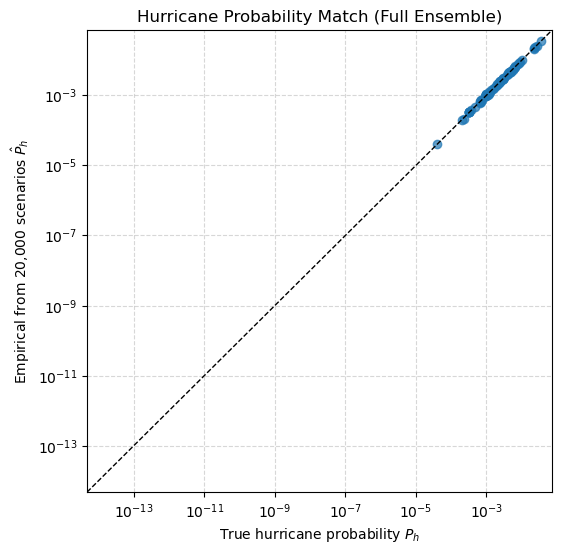

In [10]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# --- Step 1. Count hurricane occurrences across all scenarios ---
Nh = len(Ph)
Nj = len(candidates_new)
T  = candidates_new[0].annual_losses.shape[0]

n_jh_full = np.zeros((Nj, Nh), dtype=int)
for j, sc in enumerate(candidates_new):
    for (_, _, h) in sc.events:
        n_jh_full[j, h] += 1

# --- Step 2. Empirical probability estimate (per hurricane) ---
Ph_empirical = n_jh_full.sum(axis=0) / (Nj * T)

# --- Step 3. Compare with target probabilities ---
ratio = Ph_empirical / Ph
df = pd.DataFrame({
    'hurricane_id': np.arange(1, Nh+1),
    'Ph_true': Ph,
    'Ph_empirical': Ph_empirical,
    'ratio_empirical/true': ratio
})

print(df.describe())

# --- Step 4. Plot log–log match ---
plt.figure(figsize=(6,6))
plt.loglog(Ph, Ph_empirical, 'o', alpha=0.7)
lims = [Ph.min()/2, Ph.max()*2]
plt.plot(lims, lims, '--k', lw=1)
plt.xlim(lims); plt.ylim(lims)
plt.xlabel("True hurricane probability $P_h$")
plt.ylabel("Empirical from 20,000 scenarios $\hat{P}_h$")
plt.title("Hurricane Probability Match (Full Ensemble)")
plt.grid(True, which='both', ls='--', alpha=0.5)
plt.show()


#### What is `candidates_new`?

`candidates_new` is the full candidate ensemble of long-term hurricane scenarios.  
It is a Python list of length `Nj` (e.g., 50,000), where each element is one simulated
**`LongTermScenario`** object.

Each `LongTermScenario` contains:

1. **annual_losses**  
   - NumPy array of shape `(T,)` (e.g., 30 years).  
   - Total annual loss in each year of the scenario.  
   - Example: `[0, 1.2e7, 0, 4.5e6, …]`.

2. **events**  
   - List of tuples `(year_idx, step_idx, h_id)`.  
   - Each tuple represents one hurricane event:  
     - `year_idx`: which year of the scenario (0 to T-1),  
     - `step_idx`: which seasonal step (1 to 20),  
     - `h_id`: hurricane type (0 to Nh-1).  
   - Average length ≈ 9–10 events per scenario.

3. **event_days_doy** *(optional)*  
   - List of day-of-year values (between 134–350), one for each event.  
   - Provides the actual calendar day within the unequal seasonal steps.  
   - Example: `[188, 246, 310]`.

---



### Part 2: Objective Weights

The optimization balances four criteria:

1. **Loss distribution (CDF)** — error in the total-loss CDF  
2. **Inter-arrival distribution** — error in the event-gap histogram (20-step season)  
3. **Per-hurricane probabilities** — error in annual \(P_h\)  
4. **Annual loss moments** — error in mean and second moment

The objective is

$$
\min\; k_1\,E_{\mathrm{CDF}} \;+\; k_2\,E_{\mathrm{IA}} \;+\; k_3\,E_{\mathrm{prob}} \;+\; k_4\,E_{\mathrm{moments}} .
$$

We use equal weights:

$$
k_1 = k_2 = k_3 = k_4 = \tfrac{1}{4}.
$$


In [11]:
k1=k2=k3=k4=1/4

## Part 3: Loss CDF Matching

We match the **empirical CDF of total long-term loss** between the reduced set and the full candidate ensemble.

**Outputs of this step**
- `L_j` : total loss per candidate (shape `(Nj,)`)
- `Y_grid` : chosen probability grid (shape `(K,)`)
- `L_y` : quantile thresholds \(L(y_k)\) (shape `(K,)`)
- `CDF_indicator` : indicator matrix \(I_{j,k}\) (shape `(Nj, K)`)

**Notes**
- Use a **tail-heavy** `Y_grid` to emphasize high-loss behavior.
- Ties at thresholds are handled by the indicator definition; use a consistent quantile rule (e.g., NumPy’s `"linear"`).


In [12]:
import numpy as np

def total_loss_per_scenario(candidates):
    """
    Compute total T-year loss for each candidate scenario.

    Parameters
    ----------
    candidates : list of LongTermScenario
        Each has .annual_losses (shape (T,))

    Returns
    -------
    L_j : np.ndarray, shape (Nj,)
        Total loss per candidate scenario
    """
    L = np.fromiter((float(np.sum(sc.annual_losses)) for sc in candidates), dtype=float, count=len(candidates))
    return L


def build_cdf_targets(L_j, Y_grid):
    """
    Build CDF-matching targets from the full ensemble.

    Returns
    -------
    L_y : np.ndarray, shape (K,)
        Quantile thresholds at Y_grid
    CDF_indicator : np.ndarray, shape (Nj, K)
        I[j,k] = 1{L_j <= L_y[k]}
    """
    Y_grid = np.asarray(Y_grid, dtype=float)
    assert np.all((0.0 <= Y_grid) & (Y_grid <= 1.0)), "Y_grid must be in [0,1]"
    assert np.all(np.diff(Y_grid) >= 0), "Y_grid must be nondecreasing"

    L_sorted = np.sort(np.asarray(L_j, dtype=float))

    # Backward-compatible quantile call
    try:
        # NumPy >= 1.22
        L_y = np.quantile(L_sorted, Y_grid, method="linear")
    except TypeError:
        # NumPy < 1.22
        L_y = np.quantile(L_sorted, Y_grid, interpolation="linear")

    CDF_indicator = (L_j[:, None] <= L_y[None, :]).astype(float)
    return L_y, CDF_indicator


# ---- Example usage ----
# Choose a tail-heavy grid (edit if desired)
Y_grid = np.array([0.1, 0.25, 0.50, 0.75, 0.90, 0.95, 0.975, 0.99], dtype=float)

# candidates_new must already exist (from Part 1 generator)
L_j = total_loss_per_scenario(candidates_new)
L_y, CDF_indicator = build_cdf_targets(L_j, Y_grid)
print("L_y:", L_y)
print("CDF_indicator shape:", CDF_indicator.shape)

# Optional sanity checks
# Empirical CDF at thresholds under uniform weights should be close to Y_grid
emp_cdf = CDF_indicator.mean(axis=0)  # since uniform weights 1/Nj
print("Empirical CDF at thresholds:", emp_cdf)


L_y: [6.21487710e+09 9.29875805e+09 1.39620373e+10 2.02565189e+10
 2.75169640e+10 3.27059283e+10 3.78236438e+10 4.35984433e+10]
CDF_indicator shape: (20000, 8)
Empirical CDF at thresholds: [0.1   0.25  0.5   0.75  0.9   0.95  0.975 0.99 ]


## Part 4: Per-scenario Probabilities

- **Parameters**  
  - $N_A$: user-specified maximum number of scenarios in the reduced set.  
  - $p_{\min}$: minimum probability for any selected scenario, with $0 < p_{\min} \le \tfrac{1}{N_A}$.  

- **Decision variables**  
  - $z_j \in \{0,1\}$: binary indicator for whether scenario $j$ is selected.  
  - $P_j \ge 0$: probability weight of scenario $j$.  

- **Constraints**  
  - **Normalization**  
    $$
    \sum_{j=1}^{N_j} P_j = 1
    $$
  - **Cardinality**  
    $$
    \sum_{j=1}^{N_j} z_j \le N_A
    $$
  - **Linkage**  
    $$
    P_j \le z_j, \qquad P_j \ge p_{\min}\, z_j \quad \forall j
    $$


In [13]:
# ---- User choices for the reduced set ----
N_A = 100                 # max number of scenarios in the reduced set
p_min = 1.0 / (4 * N_A)   # example: 1/(4*N_A) = 0.0025 if N_A=100

# Sanity checks
assert 0.0 < p_min <= 1.0 / N_A, "Choose 0 < p_min <= 1/N_A"

## Part 5: Per-scenario Counts

We also track the number of hurricane events in each candidate scenario.

- **Per-scenario, per-hurricane count**  
  $$
  n_{jh} = \text{number of hurricanes of type } h \text{ in long-term scenario } j
  $$

- **Per-scenario total count**  
  $$
  n_j = \sum_{h=1}^{N_h} n_{jh}
  $$

Here:
- $n_{jh}$ counts how many times hurricane $h$ occurs in scenario $j$ over $T$ years.
- $n_j$ is the total number of hurricanes (all types) in scenario $j$.


In [14]:

def build_counts(candidates, Nh):
    """
    Compute per-scenario hurricane counts.

    Parameters
    ----------
    candidates : list of LongTermScenario
        Each scenario has .events = [(year, step, h_id), ...]
    Nh : int
        Number of distinct hurricane types h

    Returns
    -------
    n_jh : np.ndarray, shape (Nj, Nh)
        Counts of each hurricane h in scenario j
    n_j : np.ndarray, shape (Nj,)
        Total number of hurricanes in each scenario j
    """
    Nj = len(candidates)
    n_jh = np.zeros((Nj, Nh), dtype=int)
    n_j  = np.zeros(Nj, dtype=int)

    for j, sc in enumerate(candidates):
        for (_, _, h) in sc.events:
            n_jh[j, h] += 1
        n_j[j] = n_jh[j].sum()

    return n_jh, n_j

# ---- Example usage ----
n_jh, n_j = build_counts(candidates_new, Nh)

print("n_jh shape:", n_jh.shape)   # (Nj, Nh)
print("n_j shape:", n_j.shape)     # (Nj,)
print("Example scenario counts (first row):", n_jh[0, :10], "total =", n_j[0])


n_jh shape: (20000, 97)
n_j shape: (20000,)
Example scenario counts (first row): [0 0 0 0 0 0 0 0 0 0] total = 12


## Part 6: Inter-arrival Structure

We represent the timing of events using **inter-arrival time bins** based on hurricane step-gaps.

- **Time discretization**  
  Each year is divided into 20 unequal time steps (e.g., the first spans 51 days beginning on day 134), chosen so that each step has equal hurricane occurrence probability.

- **Inter-arrival bins**  
  Let $B$ denote a fixed set of bins over step gaps. For example:
  $$
  B = \{ [1], [2], [3\text{--}4], [5\text{--}7], [8\text{--}12], [13\text{--}20], [21\text{--}40], [41\text{--}80], [81+] \}
  $$
  Here, $[1]$ means a gap of exactly 1 step, $[2]$ means a gap of 2 steps, $[3\text{--}4]$ means gaps of 3–4 steps, and so on, up to very long quiet periods $[81+]$.

- **Definitions**
  - $\pi_b^{\text{true}}$: the *true* probability distribution of inter-arrival times across bins $b$, computed from the full candidate set.
  - $\pi_{j,b}$: the fraction of inter-arrival gaps falling into bin $b$ for scenario $j$.

These quantities allow the optimization to enforce that the reduced set matches the empirical inter-arrival structure of the full ensemble.


In [15]:
import numpy as np

# Define bins over step gaps
# Example: [1], [2], [3-4], [5-7], [8-12], [13-20], [21-40], [41-80], [81+]
INTERVAL_BINS = [(1,1), (2,2), (3,4), (5,7), (8,12), (13,20), (21,40), (41,80), (81,np.inf)]
B = len(INTERVAL_BINS)

def step_gaps_for_scenario(sc, steps_per_year=20):
    """Return inter-arrival gaps in step units for one scenario."""
    if len(sc.events) < 2:
        return np.array([], dtype=int)
    # Convert to "global step" index = year * steps_per_year + step
    global_steps = sorted([y*steps_per_year + s for (y,s,h) in sc.events])
    return np.diff(global_steps)

def gap_bin_counts(gaps, bins=INTERVAL_BINS):
    """Count how many gaps fall into each bin."""
    counts = np.zeros(len(bins), dtype=int)
    for g in gaps:
        for b, (lo, hi) in enumerate(bins):
            if lo <= g <= hi:
                counts[b] += 1
                break
    return counts

def build_interarrival_distributions(candidates, steps_per_year=20, bins=INTERVAL_BINS):
    """
    Compute per-scenario and full-ensemble inter-arrival distributions.

    Returns
    -------
    pi_true : np.ndarray, shape (B,)
        True distribution over bins from all scenarios combined
    pi_jb : np.ndarray, shape (Nj, B)
        Fraction of gaps in each bin for each scenario j
    """
    Nj = len(candidates)
    B = len(bins)

    pi_jb = np.zeros((Nj, B), dtype=float)
    total_counts = np.zeros(B, dtype=int)
    total_gaps = 0

    for j, sc in enumerate(candidates):
        gaps = step_gaps_for_scenario(sc, steps_per_year)
        if len(gaps) == 0:
            continue
        counts = gap_bin_counts(gaps, bins)
        pi_jb[j,:] = counts / counts.sum()
        total_counts += counts
        total_gaps += counts.sum()

    pi_true = total_counts / total_gaps if total_gaps > 0 else np.zeros(B)
    return pi_true, pi_jb

# ---- Example usage ----
pi_true, pi_jb = build_interarrival_distributions(candidates_new, steps_per_year=20)

print("pi_true (true inter-arrival distribution):", pi_true)
print("pi_jb shape:", pi_jb.shape)  # (Nj, B)
print("Example pi_jb row (scenario 0):", pi_jb[0])


pi_true (true inter-arrival distribution): [0.01764532 0.01792402 0.03390293 0.04978894 0.07521469 0.10908859
 0.21026901 0.25191753 0.23424899]
pi_jb shape: (20000, 9)
Example pi_jb row (scenario 0): [0.09090909 0.         0.09090909 0.09090909 0.09090909 0.18181818
 0.09090909 0.18181818 0.18181818]


## Part 7: Annual Loss Moments (control year-to-year behavior)

Let \(L_{j,t}\) be the annual loss in year \(t=1,\ldots,T\) for candidate scenario \(j\).

- **Per-scenario annual mean**
  $$
  m_{1j} \;=\; \frac{1}{T}\sum_{t=1}^{T} L_{j,t}
  $$

- **Per-scenario annual second moment**
  $$
  m_{2j} \;=\; \frac{1}{T}\sum_{t=1}^{T} \big(L_{j,t}\big)^2
  $$

- **Full-ensemble (“true”) moments** (uniformly averaging all scenario-years)
  $$
  m_{1}^{\text{true}} \;=\; \mathbb{E}[L_{j,t}], 
  \qquad
  m_{2}^{\text{true}} \;=\; \mathbb{E}\!\big[L_{j,t}^{2}\big].
  $$

In the reduced set with probabilities \(P_j\) (summing to 1), we match moments via
$$
\sum_{j=1}^{N_j} P_j\, m_{1j} \;\approx\; m_{1}^{\text{true}},
\qquad
\sum_{j=1}^{N_j} P_j\, m_{2j} \;\approx\; m_{2}^{\text{true}},
$$
using nonnegative slacks and weight \(k_4\) in the objective.


In [16]:


def build_annual_moments(candidates):
    """
    Compute per-scenario annual mean/second-moment and the full-ensemble true moments.

    Returns
    -------
    m1_j : (Nj,)  per-scenario annual mean
    m2_j : (Nj,)  per-scenario annual second moment
    m1_true : ()  true annual mean over all scenario-years
    m2_true : ()  true annual second moment over all scenario-years
    """
    Nj = len(candidates)

    # Per-scenario moments
    m1_j = np.fromiter((float(np.mean(sc.annual_losses)) for sc in candidates),
                       dtype=float, count=Nj)
    m2_j = np.fromiter((float(np.mean(sc.annual_losses**2)) for sc in candidates),
                       dtype=float, count=Nj)

    # True (full-ensemble) moments: pool all years equally
    all_years = np.concatenate([sc.annual_losses for sc in candidates]).astype(float)
    m1_true = float(all_years.mean())
    m2_true = float((all_years**2).mean())

    return m1_j, m2_j, m1_true, m2_true

# --- Example usage (with your candidates_new) ---
m1_j, m2_j, m1_true, m2_true = build_annual_moments(candidates_new)

print("m1_j shape:", m1_j.shape)
print("m2_j shape:", m2_j.shape)
print("m1_true:", m1_true)
print("m2_true:", m2_true)



m1_j shape: (20000,)
m2_j shape: (20000,)
m1_true: 523788825.1859257
m2_true: 2.8827029298344556e+18


# Decision Variables

We optimize over a reduced set of long-term scenarios by selecting scenarios and assigning them probabilities. We also use nonnegative slack variables to allow small mismatches in each criterion.

- **Scenario probability**
  - $P_j \ge 0$: occurrence probability for candidate scenario $j$.
  - Normalization: 
    $$
    \sum_{j=1}^{N_j} P_j = 1
    $$
  - If $P_j = 0$, scenario $j$ is effectively excluded.

- **Selection indicator**
  - $z_j \in \{0,1\}$: 1 if scenario $j$ is selected, else 0.
  - Cardinality: 
    $$
    \sum_{j=1}^{N_j} z_j \le N_A
    $$
  - Linkage: 
    $$
    P_j \le z_j, \qquad P_j \ge p_{\min}\, z_j
    $$

- **Slack variables (all $\ge 0$)**
  - **CDF matching** at each $y \in \mathcal{Y}$: $e_{1,y}^{+},\; e_{1,y}^{-}$
  - **Inter-arrival bins** $b \in B$: $e_{2,b}^{+},\; e_{2,b}^{-}$
  - **Per-hurricane annual probability** for each $h=1,\dots,N_h$: $e_{3,h}^{+},\; e_{3,h}^{-}$
  - **Annual mean**: $e_{4}^{+},\; e_{4}^{-}$
  - **Annual second moment**: $e_{5}^{+},\; e_{5}^{-}$

The global objective is a weighted sum of all slacks:

$$
\min\; k_1 \sum_{y \in \mathcal{Y}} \big(e_{1,y}^{+}+e_{1,y}^{-}\big)
\;+\; k_2 \sum_{b \in B} \big(e_{2,b}^{+}+e_{2,b}^{-}\big)
\;+\; k_3 \sum_{h=1}^{N_h} \big(e_{3,h}^{+}+e_{3,h}^{-}\big)
\;+\; k_4 \big( e_{4}^{+}+e_{4}^{-}+e_{5}^{+}+e_{5}^{-} \big).
$$


# Optimization Formulation

We minimize a weighted sum of errors over four matching criteria, subject to feasibility and selection constraints.

---

**Objective**

$$
\min \;
k_1 \sum_{y \in \mathcal{Y}} \big(e_{1,y}^{+} + e_{1,y}^{-}\big)
\;+\; k_2 \sum_{b \in B} \big(e_{2,b}^{+} + e_{2,b}^{-}\big)
\;+\; k_3 \sum_{h=1}^{N_h} \big(e_{3,h}^{+} + e_{3,h}^{-}\big)
\;+\; k_4 \Big( e_{4}^{+} + e_{4}^{-} + e_{5}^{+} + e_{5}^{-} \Big)
$$

with $k_1 + k_2 + k_3 + k_4 = 1$.

---

**Constraints**

1. **CDF matching**
   $$
   \sum_{j=1}^{N_j} P_j \, \mathbf{1}\{L_j \le l_y\}
   - e_{1,y}^{+} + e_{1,y}^{-} \;=\; y,
   \qquad \forall y \in \mathcal{Y}
   $$

2. **Inter-arrival distribution**
   $$
   \sum_{j=1}^{N_j} P_j \, \pi_{j,b}
   - e_{2,b}^{+} + e_{2,b}^{-} \;=\; \pi_b^{\text{true}},
   \qquad \forall b \in B
   $$

3. **Per-hurricane occurrence probabilities**
   $$
   \frac{1}{T}\sum_{j=1}^{N_j} P_j \, n_{j,h}
   - e_{3,h}^{+} + e_{3,h}^{-} \;=\; P_h,
   \qquad \forall h=1,\dots,N_h
   $$

4. **Selection linkage**
   $$
   P_j \le z_j, \qquad \forall j
   $$

5. **Probability floor and binary selection**
   $$
   P_j \ge p_{\min}\, z_j, \quad z_j \in \{0,1\}, \qquad \forall j
   $$

6. **Cardinality**
   $$
   \sum_{j=1}^{N_j} z_j \le N_A
   $$

7. **Probability normalization**
   $$
   \sum_{j=1}^{N_j} P_j = 1
   $$

8. **Non-negativity**
   $$
   P_j \ge 0, \qquad \forall j
   $$

9. **Annual mean loss**
   $$
   \sum_{j=1}^{N_j} P_j \, m_{1j} - e_{4}^{+} + e_{4}^{-} \;=\; m_{1}^{\text{true}}
   $$

10. **Annual second-moment loss**
    $$
    \sum_{j=1}^{N_j} P_j \, m_{2j} - e_{5}^{+} + e_{5}^{-} \;=\; m_{2}^{\text{true}}
    $$

11. **Slack non-negativity**
    $$
    e_{1,y}^{+}, e_{1,y}^{-}, \;
    e_{2,b}^{+}, e_{2,b}^{-}, \;
    e_{3,h}^{+}, e_{3,h}^{-}, \;
    e_{4}^{+}, e_{4}^{-}, \;
    e_{5}^{+}, e_{5}^{-} \;\;\ge 0
    $$

---

**Interpretation**

- **Constraint (1)** matches the total loss CDF at each probability level $y \in \mathcal{Y}$, with slacks $e_{1,y}^{+}$ and $e_{1,y}^{-}$ capturing over/underestimation.
- **Constraint (2)** matches the inter-arrival time distribution, with slacks $e_{2,b}^{\pm}$.
- **Constraint (3)** matches per-hurricane annual occurrence probabilities $P_h$, with slacks $e_{3,h}^{\pm}$.
- **Constraint (4)** ensures probabilities are only assigned to selected scenarios.
- **Constraint (5)** enforces binary selection and a minimum probability for each selected scenario.
- **Constraint (6)** limits the number of selected scenarios to at most $N_A$.
- **Constraint (7)** ensures probabilities sum to 1.
- **Constraint (8)** enforces non-negativity of probabilities.
- **Constraints (9)–(10)** enforce annual mean and second-moment matching, with slacks $e_{4}^{\pm}$ and $e_{5}^{\pm}$.
- **Constraint (11)** requires all slacks to be nonnegative.


In [17]:
# ===========================
# Scenario Reduction via MILP (Gurobi version, with milestone tracking)
# Requires: pip install gurobipy  (and a valid Gurobi license)
# ===========================

import time
import numpy as np
from dataclasses import dataclass
import gurobipy as gp
from gurobipy import GRB, quicksum


# ---------- Config ----------
@dataclass
class SRConfig:
    subset_size: int = None       # e.g., 5000 to test; None = use full Nj
    time_limit_sec: int = 1800    # 30 minutes
    mip_gap: float = 0.01         # 1% MIP gap
    threads: int = 0              # 0 = Gurobi default (uses all cores)
    verbose: bool = True          # solver log on/off
    seed: int = 0                 # for reproducibility (node selection etc.)


# ---------- Helper ----------
def _maybe_subset(Nj, *arrays, subset_size=None, rng_seed=0):
    """Optionally take a subset of scenarios to make a first run faster."""
    if subset_size is None or subset_size >= Nj:
        idx = np.arange(Nj, dtype=int)
        return idx, arrays
    rng = np.random.default_rng(rng_seed)
    idx = np.sort(rng.choice(Nj, size=subset_size, replace=False))
    out = []
    for A in arrays:
        if isinstance(A, np.ndarray) and A.ndim >= 1 and A.shape[0] == Nj:
            out.append(A[idx] if A.ndim == 1 else A[idx, ...])
        else:
            out.append(A)
    return idx, out


# ---------- Callback ----------
def milestone_callback(model, where):
    """Track key milestones: feasible solution, 1% gap, 0.5% gap."""
    if where == GRB.Callback.MIP:
        t_now = time.perf_counter() - model._t0
        has_sol = model.cbGet(GRB.Callback.MIP_SOLCNT) > 0
        if has_sol and model._t_feas is None:
            model._t_feas = t_now

        best_obj = model.cbGet(GRB.Callback.MIP_OBJBST)
        best_bound = model.cbGet(GRB.Callback.MIP_OBJBND)
        if best_obj < GRB.INFINITY and best_bound < GRB.INFINITY:
            gap = abs(best_obj - best_bound) / (abs(best_obj) + 1e-12)
            for g in model._milestones:
                if model._milestones[g] is None and gap <= g:
                    model._milestones[g] = t_now


# ---------- Main Solver ----------
def solve_scenario_reduction_mip(
    Y_grid, CDF_indicator, pi_true, pi_jb, n_jh, Ph,
    m1_j, m2_j, m1_true, m2_true,
    T, N_A, p_min, k1, k2, k3, k4,
    cfg: SRConfig = SRConfig(), equal_weights=False,
    z_prev=None,                # optional: binary array from previous run
    soft_nesting=False,         # if True, only encourage nesting (not require)
    epsilon_nest=1e-6           # small weight for soft nesting reward
):
    """
    Scenario-reduction MILP (scaled) in Gurobi with optional nesting.
    If z_prev is provided, all previously selected scenarios must (or should) be kept.
    """

    # ---------- Shapes & checks ----------
    Nj = CDF_indicator.shape[0]
    K = len(Y_grid)
    B = pi_jb.shape[1]
    Nh = len(Ph)
    assert abs((k1 + k2 + k3 + k4) - 1.0) < 1e-12, "k1..k4 must sum to 1"
    if z_prev is not None:
        assert len(z_prev) == Nj, "z_prev length must match total scenarios."

    # ---------- Optional subset ----------
    subset_idx, (CDF_indicator_s, pi_jb_s, n_jh_s, m1_j_s, m2_j_s) = _maybe_subset(
        Nj, CDF_indicator, pi_jb, n_jh, m1_j, m2_j,
        subset_size=cfg.subset_size, rng_seed=cfg.seed
    )
    Nj_eff = len(subset_idx)
    valid_h_idx = np.flatnonzero(n_jh_s.sum(axis=0) > 0)

    if cfg.verbose:
        print(f"[SR] Using Nj={Nj_eff} (of {Nj}) | N_A={N_A} | Nesting={z_prev is not None}")
        print(f"[SR] k = ({k1}, {k2}, {k3}, {k4})")

    # ---------- Scaling factors ----------
    eps = 1e-12
    s_cdf = 1.0
    s_pi  = 1.0 / (np.mean(np.abs(pi_true)) + eps)
    s_ph  = 1.0 / (np.mean(np.abs(Ph)) + eps)
    s_m1  = 1.0 / (abs(m1_true) + eps)
    s_m2  = 1.0 / (abs(m2_true) + eps)
    invT  = 1.0 / float(T)

    # ---------- Model ----------
    m = gp.Model("scenario_reduction")
    m.Params.TimeLimit  = cfg.time_limit_sec
    m.Params.MIPGap     = cfg.mip_gap
    if cfg.threads:
        m.Params.Threads = cfg.threads
    m.Params.OutputFlag = 1 if cfg.verbose else 0
    m.Params.Seed       = cfg.seed

    # ---------- Variables ----------
    P  = m.addVars(Nj_eff, lb=0.0, vtype=GRB.CONTINUOUS, name="P")
    z  = m.addVars(Nj_eff, vtype=GRB.BINARY, name="z")

    e1p = m.addVars(K, lb=0.0, name="e1p")
    e1m = m.addVars(K, lb=0.0, name="e1m")
    e2p = m.addVars(B, lb=0.0, name="e2p")
    e2m = m.addVars(B, lb=0.0, name="e2m")
    H   = len(valid_h_idx)
    e3p = m.addVars(H, lb=0.0, name="e3p")
    e3m = m.addVars(H, lb=0.0, name="e3m")
    e4p = m.addVar(lb=0.0, name="e4p")
    e4m = m.addVar(lb=0.0, name="e4m")
    e5p = m.addVar(lb=0.0, name="e5p")
    e5m = m.addVar(lb=0.0, name="e5m")

    # ---------- Constraints ----------
    if equal_weights:
        if cfg.verbose:
            print("[SR] Equal-weights mode.")
        m.addConstrs(P[j] == (1.0 / N_A) * z[j] for j in range(Nj_eff))
    else:
        m.addConstrs(P[j] <= z[j]         for j in range(Nj_eff))
        m.addConstrs(P[j] >= p_min * z[j] for j in range(Nj_eff))

    m.addConstr(z.sum() <= N_A, name="cardinality")
    m.addConstr(P.sum() == 1.0, name="prob_sum")

    # --- Optional nesting ---
    objective_bonus = 0.0
    if z_prev is not None:
        z_prev_s = z_prev[subset_idx]
        for j in range(Nj_eff):
            if z_prev_s[j] > 0.5:
                if not soft_nesting:
                    m.addConstr(z[j] >= 1, name=f"nest_{j}")
                else:
                    objective_bonus += -epsilon_nest * z[j]

    # --- CDF matching ---
    for k in range(K):
        m.addConstr(
            quicksum(P[j] * float(CDF_indicator_s[j, k]) for j in range(Nj_eff)) * s_cdf
            - e1p[k] + e1m[k] == float(Y_grid[k]) * s_cdf,
            name=f"CDF_{k}"
        )

    # --- π (interarrival) matching ---
    for b in range(B):
        m.addConstr(
            quicksum(P[j] * float(pi_jb_s[j, b]) for j in range(Nj_eff)) * s_pi
            - e2p[b] + e2m[b] == float(pi_true[b]) * s_pi,
            name=f"pi_{b}"
        )

    # --- Per-hurricane probabilities ---
    for i, h in enumerate(valid_h_idx):
        m.addConstr(
            quicksum(P[j] * (invT * float(n_jh_s[j, h])) for j in range(Nj_eff)) * s_ph
            - e3p[i] + e3m[i] == float(Ph[h]) * s_ph,
            name=f"Ph_{h}"
        )

    # --- Moments ---
    m.addConstr(
        quicksum(P[j] * float(m1_j_s[j]) for j in range(Nj_eff)) * s_m1 - e4p + e4m == float(m1_true) * s_m1,
        name="m1"
    )
    m.addConstr(
        quicksum(P[j] * float(m2_j_s[j]) for j in range(Nj_eff)) * s_m2 - e5p + e5m == float(m2_true) * s_m2,
        name="m2"
    )

    # ---------- Objective ----------
    obj = (
        k1 * quicksum(e1p[k] + e1m[k] for k in range(K)) +
        k2 * quicksum(e2p[b] + e2m[b] for b in range(B)) +
        k3 * quicksum(e3p[i] + e3m[i] for i in range(H)) +
        k4 * (e4p + e4m + e5p + e5m)
    )
    if soft_nesting and z_prev is not None and objective_bonus != 0.0:
        obj += objective_bonus
    m.setObjective(obj, GRB.MINIMIZE)

    # ---------- Milestone setup ----------
    m._t0 = time.perf_counter()
    m._t_feas = None
    m._milestones = {0.01: None, 0.005: None}

    # ---------- Solve ----------
    m.optimize(milestone_callback)
    elapsed = time.perf_counter() - m._t0
    status = m.Status

    if cfg.verbose:
        print(f"[SR] gurobi status: {status} | Obj: {m.ObjVal if m.SolCount else None}")

    # ---------- Extract solution ----------
    if m.SolCount == 0:
        return {
            "status": status,
            "objective": None,
            "selected_idx": np.array([], dtype=int),
            "selected_probs": np.array([], dtype=float),
            "Nj_eff": Nj_eff,
            "elapsed_sec": elapsed,
            "time_feasible": m._t_feas,
            "time_gap_1pct": m._milestones[0.01],
            "time_gap_0p5pct": m._milestones[0.005],
            "final_gap": getattr(m, "MIPGap", None),
            "hit_time_limit": (m.Status == GRB.TIME_LIMIT),
            "model": m,
            "s_pi": s_pi, "s_ph": s_ph, "s_m1": s_m1, "s_m2": s_m2
        }

    P_sol = np.array([P[j].X for j in range(Nj_eff)], dtype=float)
    z_raw = np.array([z[j].X for j in range(Nj_eff)], dtype=float)
    z_sol = np.rint(z_raw).astype(int)

    sel_local = np.flatnonzero(z_sol == 1)
    selected_idx = sel_local if (cfg.subset_size is None or cfg.subset_size >= Nj) else subset_idx[sel_local]

    selected_probs = P_sol[sel_local]
    if selected_probs.sum() > 0:
        selected_probs = selected_probs / selected_probs.sum()

    return {
        "status": status,
        "objective": float(m.ObjVal),
        "selected_idx": selected_idx,
        "selected_probs": selected_probs,
        "Nj_eff": Nj_eff,
        "elapsed_sec": elapsed,
        "time_feasible": m._t_feas,
        "time_gap_1pct": m._milestones[0.01],
        "time_gap_0p5pct": m._milestones[0.005],
        "final_gap": getattr(m, "MIPGap", None),
        "hit_time_limit": (m.Status == GRB.TIME_LIMIT),
        "model": m,
        "s_pi": s_pi, "s_ph": s_ph, "s_m1": s_m1, "s_m2": s_m2
    }


In [18]:
def validate_solution_scaled(
    selected_idx, selected_probs,
    Y_grid, CDF_indicator, pi_true, pi_jb, n_jh, Ph,
    m1_j, m2_j, m1_true, m2_true, T,
    *,
    equal_weights=False,
    N_A=None,
    s_pi=None, s_ph=None, s_m1=None, s_m2=None, s_cdf=1.0,
    rel_tol=1e-1,
):
    """
    Robust, scale-consistent validation with multi-metric criteria.
    Uses scaled residuals (unitless). Passes a block if at least 2 of 3
    metrics (max, RMS, 95th) are within rel_tol.
    """

    if len(selected_idx) == 0:
        print("⚠️ No scenarios selected.")
        return False

    # --- normalize weights ---
    P = np.asarray(selected_probs, float)
    if equal_weights:
        P[:] = 1.0 / len(P)
    if P.sum() <= 0:
        print("⚠️ Probabilities sum to zero — skipping validation.")
        return False
    P /= P.sum()

    # --- tolerances ---
    abs_tol = rms_tol = p95_tol = rel_tol

    # --- scaling factors ---
    eps = 1e-12
    if s_pi is None: s_pi = 1.0 / (np.mean(np.abs(pi_true)) + eps)
    if s_ph is None: s_ph = 1.0 / (np.mean(np.abs(Ph)) + eps)
    if s_m1 is None: s_m1 = 1.0 / (abs(m1_true) + eps)
    if s_m2 is None: s_m2 = 1.0 / (abs(m2_true) + eps)

    # --- pull selected ---
    C_sel = CDF_indicator[selected_idx, :]
    pi_sel = pi_jb[selected_idx, :]
    n_sel = n_jh[selected_idx, :]
    m1_sel = m1_j[selected_idx]
    m2_sel = m2_j[selected_idx]

    invT = 1.0 / float(T)
    cdf_res = s_cdf * ((P[:, None] * C_sel).sum(axis=0) - Y_grid)
    ia_res  = s_pi  * ((P[:, None] * pi_sel).sum(axis=0) - pi_true)
    ph_res  = s_ph  * ((P[:, None] * (invT * n_sel)).sum(axis=0) - Ph)
    m1_res  = s_m1  * (np.dot(P, m1_sel) - m1_true)
    m2_res  = s_m2  * (np.dot(P, m2_sel) - m2_true)

    def check_block(x, name):
        x = np.abs(x)
        maxv = np.max(x)
        rmsv = np.sqrt(np.mean(x**2))
        p95v = np.percentile(x, 95)
        passed = sum([
            maxv <= abs_tol,
            rmsv <= rms_tol,
            p95v <= p95_tol
        ]) >= 2
        print(f"{name}: max={maxv:.3e}, RMS={rmsv:.3e}, 95th={p95v:.3e} -> {passed}")
        return passed

    cdf_ok = check_block(cdf_res, "CDF")
    ia_ok  = check_block(ia_res,  "IA ")
    ph_ok  = check_block(ph_res,  "Ph ")
    m1_ok  = abs(m1_res) <= abs_tol
    m2_ok  = abs(m2_res) <= abs_tol

    print(f"m1: |scaled|={abs(m1_res):.3e} -> {m1_ok}")
    print(f"m2: |scaled|={abs(m2_res):.3e} -> {m2_ok}")

    ok = all([cdf_ok, ia_ok, ph_ok, m1_ok, m2_ok])
    print(f"Overall -> {ok}")
    return ok


In [19]:
import multiprocessing
print(multiprocessing.cpu_count())


20


In [20]:
# ============================================
# Scenario Reduction: batch runs + figures
#  - Baseline: single reference case
#  - Size sweep: nested, equal vs free weights
# ============================================

import os, time, numpy as np, pandas as pd, multiprocessing
from datetime import datetime

# ---------- Helpers ----------

def hhi(P):
    P = np.asarray(P, float)
    s = P.sum()
    if s <= 0:
        return 0.0
    Pn = P / s
    return float(np.sum(Pn**2))


def run_one(N_A, equal_weights, cfg,
            Y_grid, CDF_indicator, pi_true, pi_jb, n_jh, Ph,
            m1_j, m2_j, m1_true, m2_true, T,
            z_prev=None, use_nesting=False, soft_nesting=False,
            p_min=0.0):
    """Single SR run with optional nesting."""
    k1 = k2 = k3 = k4 = 0.25

    t0 = time.perf_counter()
    res = solve_scenario_reduction_mip(
        Y_grid, CDF_indicator, pi_true, pi_jb, n_jh, Ph,
        m1_j, m2_j, m1_true, m2_true,
        T=T, N_A=N_A, p_min=p_min,
        k1=k1, k2=k2, k3=k3, k4=k4,
        cfg=cfg, equal_weights=equal_weights,
        z_prev=z_prev if use_nesting else None,
        soft_nesting=soft_nesting
    )
    elapsed = time.perf_counter() - t0

    sel = np.asarray(res.get("selected_idx", []), int)
    P   = np.asarray(res.get("selected_probs", []), float)
    obj = float(res.get("objective", np.nan))
    status = str(res.get("status"))
    hhi_val = hhi(P)

    return dict(
        N_A=N_A,
        mode=("equal" if equal_weights else "free"),
        objective=obj,
        elapsed_sec=elapsed,
        status=status,
        num_selected=len(sel),
        hhi=hhi_val,
        selected_idx=sel,
        selected_probs=P,
        nesting=("nested" if use_nesting else "non_nested"),
        p_min=p_min
    )

# ---------- Global setup ----------

sizes = [60, 80, 100, 120, 140]     # size sweep
modes = [True, False]               # equal / free weights
soft_nesting = False

cfg = SRConfig(
    subset_size=None,
    time_limit_sec=3600,
    mip_gap=0.005,
    # Gurobi will automatically multithread
    threads=max(1, multiprocessing.cpu_count()),
    verbose=True
)

os.makedirs("sr_runs", exist_ok=True)
print("Start:", datetime.now().strftime("%Y-%m-%d %H:%M:%S"))

rows = []
total_Nj = CDF_indicator.shape[0]


Start: 2026-02-03 17:26:56


In [21]:
import gurobipy as gp
print("Gurobi package version:", gp.gurobi.version())


Gurobi package version: (12, 0, 3)


In [22]:
# =====================================================
# 1️⃣ BASELINE CASE (reference)
# =====================================================
BASE_N = 100
BASE_PMIN = 1e-5

print(f"\n=== BASELINE RUN ===")
print(f"N_A={BASE_N}, mode=free, non-nested, p_min={BASE_PMIN:.2e}")

r = run_one(BASE_N, False, cfg,
            Y_grid, CDF_indicator, pi_true, pi_jb, n_jh, Ph,
            m1_j, m2_j, m1_true, m2_true, T,
            use_nesting=False, p_min=BASE_PMIN)

rows.append({k: v for k, v in r.items()
             if k not in ("selected_idx", "selected_probs")})

np.savez_compressed(f"sr_runs/sr_run_N{BASE_N}_free_baseline.npz",
                    selected_idx=r["selected_idx"],
                    selected_probs=r["selected_probs"],
                    objective=r["objective"],
                    N_A=BASE_N, mode='free',
                    nesting='non_nested', p_min=BASE_PMIN)

print(f"-> obj={r['objective']:.6g} | HHI={r['hhi']:.4f} | "
      f"selected={r['num_selected']} | status={r['status']} | "
      f"time={r['elapsed_sec']:.1f}s")


=== BASELINE RUN ===
N_A=100, mode=free, non-nested, p_min=1.00e-05
[SR] Using Nj=20000 (of 20000) | N_A=100 | Nesting=False
[SR] k = (0.25, 0.25, 0.25, 0.25)
Set parameter WLSAccessID
Set parameter WLSSecret
Set parameter LicenseID to value 2733012
Academic license 2733012 - for non-commercial use only - registered to wa___@udel.edu
Set parameter TimeLimit to value 3600
Set parameter MIPGap to value 0.005
Set parameter Threads to value 20
Set parameter OutputFlag to value 1
Set parameter Seed to value 0
Gurobi Optimizer version 12.0.3 build v12.0.3rc0 (win64 - Windows 11+.0 (26200.2))

CPU model: 12th Gen Intel(R) Core(TM) i9-12900H, instruction set [SSE2|AVX|AVX2]
Thread count: 14 physical cores, 20 logical processors, using up to 20 threads

Non-default parameters:
TimeLimit  3600
MIPGap  0.005
Threads  20

Academic license 2733012 - for non-commercial use only - registered to wa___@udel.edu
Optimize a model with 40100 rows, 40196 columns and 521384 nonzeros
Model fingerprint: 0x23

In [23]:
# save out indices#
# --- Load full event matrix ---
event_df = pd.read_csv("scenario_event_matrix.csv", dtype=str)

# --- Load reduced SR results ---
sr_path = "sr_runs/sr_run_N100_free_baseline.npz"
sr_data = np.load(sr_path)
selected_idx   = sr_data["selected_idx"]
selected_probs = sr_data["selected_probs"]

# --- Extract reduced subset (and attach weights) ---
event_df_reduced = event_df.iloc[selected_idx].reset_index(drop=True)
event_df_reduced.insert(0, "prob", selected_probs)

# --- Save reduced event matrix ---
out_path = f"scenario_event_matrix_reduced_N{len(selected_idx)}.csv"
event_df_reduced.to_csv(out_path, index=False)
print(f"Saved reduced event matrix: {out_path} | Shape: {event_df_reduced.shape}")


Saved reduced event matrix: scenario_event_matrix_reduced_N97.csv | Shape: (97, 31)


In [24]:
# =====================================================
# 2️⃣ SIZE-SWEEP SERIES (nested, p_min=0)
# =====================================================
print("\n=== SIZE-SWEEP SERIES (nested, p_min=0) ===")
for eq in modes:
    z_prev = np.zeros(total_Nj, int)
    for N_A in sizes:
        print(f"\n--- Size-sweep: N_A={N_A}, "
              f"{'equal' if eq else 'free'} weights ---")
        r = run_one(N_A, eq, cfg,
                    Y_grid, CDF_indicator, pi_true, pi_jb, n_jh, Ph,
                    m1_j, m2_j, m1_true, m2_true, T,
                    z_prev=z_prev, use_nesting=True, p_min=0)

        rows.append({k: v for k, v in r.items()
                     if k not in ("selected_idx", "selected_probs")})

        run_id = f"N{N_A}_{'equal' if eq else 'free'}_nested"
        np.savez_compressed(f"sr_runs/sr_run_{run_id}.npz",
                            selected_idx=r["selected_idx"],
                            selected_probs=r["selected_probs"],
                            objective=r["objective"],
                            N_A=N_A, mode=('equal' if eq else 'free'),
                            nesting='nested', p_min=0)

        print(f"-> obj={r['objective']:.6g} | HHI={r['hhi']:.4f} | "
              f"selected={r['num_selected']} | status={r['status']} | "
              f"time={r['elapsed_sec']:.1f}s")

        # Enforce hard nesting
        z_prev[:] = 0
        z_prev[r["selected_idx"]] = 1


# ---------- Save summary ----------
df_runs = pd.DataFrame(rows).sort_values(["mode", "nesting", "N_A"])
df_runs.to_csv("sr_runs/fig_hhi_runs_all.csv", index=False)
print("\n✅ Saved summary -> sr_runs/fig_hhi_runs_all.csv")


=== SIZE-SWEEP SERIES (nested, p_min=0) ===

--- Size-sweep: N_A=60, equal weights ---
[SR] Using Nj=20000 (of 20000) | N_A=60 | Nesting=True
[SR] k = (0.25, 0.25, 0.25, 0.25)
Set parameter TimeLimit to value 3600
Set parameter MIPGap to value 0.005
Set parameter Threads to value 20
Set parameter OutputFlag to value 1
Set parameter Seed to value 0
[SR] Equal-weights mode.
Gurobi Optimizer version 12.0.3 build v12.0.3rc0 (win64 - Windows 11+.0 (26200.2))

CPU model: 12th Gen Intel(R) Core(TM) i9-12900H, instruction set [SSE2|AVX|AVX2]
Thread count: 14 physical cores, 20 logical processors, using up to 20 threads

Non-default parameters:
TimeLimit  3600
MIPGap  0.005
Threads  20

Academic license 2733012 - for non-commercial use only - registered to wa___@udel.edu
Optimize a model with 20100 rows, 40196 columns and 481384 nonzeros
Model fingerprint: 0x2ecc1214
Variable types: 20196 continuous, 20000 integer (20000 binary)
Coefficient statistics:
  Matrix range     [3e-04, 8e+01]
  Objec

In [24]:
import os, pickle
import numpy as np

# ---------------------------------------------
# 1) NumPy-compat quantile helper (use once)
# ---------------------------------------------
def quantile_linear(a, q, *, ignore_nan=False):
    """
    Version-compatible 'linear' quantile.
    Falls back to interpolation='linear' on older NumPy.
    """
    fn = np.nanquantile if ignore_nan else np.quantile
    try:
        return fn(a, q, method="linear")          # NumPy ≥ 1.22
    except TypeError:
        return fn(a, q, interpolation="linear")   # Older NumPy

# ---------------------------------------------
# 2) Full-ensemble cache (compute or load)
# ---------------------------------------------
def compute_full_ensemble_cache(candidates, Ph, Y_grid, cache_path="sr_runs/full_ensemble_cache.pkl"):
    """
    Build (or load) a cache from the FULL ensemble of long-term scenarios.
    Contents:
      - Nj, T
      - l_y_true: CDF targets for total loss at the quantile levels in Y_grid
      - m1_true, m2_true: annual mean & second moment over all scenarios/years
      - L_full_sum: total loss per scenario (useful for diagnostics/plots)
      - Ph_input: the hurricane annual probabilities you passed in (for reference)
    Notes:
      - Uses your simulated 'candidates' list (LongTermScenario objects).
      - Does NOT recompute inter-arrival targets (π^true); you already have those.
    """
    os.makedirs(os.path.dirname(cache_path), exist_ok=True)

    # Load if already cached
    if os.path.exists(cache_path):
        with open(cache_path, "rb") as f:
            cache = pickle.load(f)
        # quick sanity check: same number of scenarios and same Y_grid
        if cache.get("Nj") == len(candidates) and np.allclose(cache.get("Y_grid", []), Y_grid):
            print(f"[full-cache] Loaded existing cache: {cache_path}")
            return cache
        else:
            print("[full-cache] Existing cache mismatches current run; rebuilding...")

    # Assemble annual loss matrix: shape (Nj, T)
    L_full = np.vstack([sc.annual_losses for sc in candidates])  # (Nj, T)
    Nj, T = L_full.shape

    # CDF targets from total losses across Nj scenarios
    L_tot_full = L_full.sum(axis=1)                               # total loss per scenario
    l_y_true = quantile_linear(L_tot_full, Y_grid)                # vector same length as Y_grid

    # Annual moments (over all Nj*T years)
    m1_true = float(np.mean(L_full))                              # E[L]
    m2_true = float(np.mean(L_full**2))                           # E[L^2]

    cache = {
        "Nj": Nj,
        "T": T,
        "Y_grid": np.array(Y_grid, dtype=float),
        "l_y_true": np.array(l_y_true, dtype=float),
        "m1_true": m1_true,
        "m2_true": m2_true,
        "L_full_sum": L_tot_full.astype(float),                   # keep for diagnostics/plots
        "Ph_input": np.array(Ph, dtype=float),                    # just for reference
    }

    with open(cache_path, "wb") as f:
        pickle.dump(cache, f, protocol=pickle.HIGHEST_PROTOCOL)
    print(f"[full-cache] Saved cache to: {cache_path}")
    return cache

# ---------------------------------------------
# 3) Call it exactly like this
# ---------------------------------------------
full_cache = compute_full_ensemble_cache(
    candidates_new,  # your list of LongTermScenario
    Ph,              # hurricane annual probabilities (97-long)
    Y_grid,          # quantile levels you match in the CDF objective
    cache_path="sr_runs/full_ensemble_cache.pkl"
)



[full-cache] Loaded existing cache: sr_runs/full_ensemble_cache.pkl


# Visualization

No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
C:\Users\jinze\AppData\Local\Temp\ipykernel_21060\684885131.py:154: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


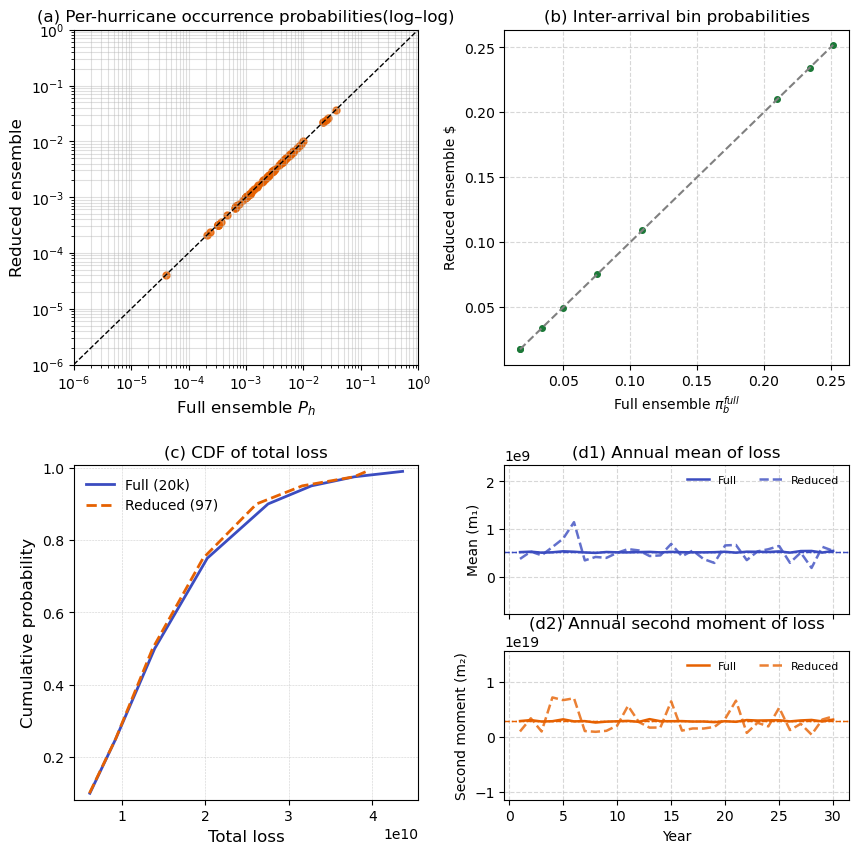

✅ Saved -> sr_runs/fig2_core_checks_baseline.png


In [26]:
import numpy as np
import matplotlib.pyplot as plt

# ---------- Load the baseline selection ----------
BASE_N    = 100
BASE_sel = 97
BASE_MODE = "free"       # ✅ baseline uses equal weights
BASE_NEST = "non_nested"  # ✅ match .npz naming convention from batch script

run_id = f"N{BASE_N}_{BASE_MODE}_baseline"  # ✅ file saved as sr_run_N100_equal_baseline.npz
art = np.load(f"sr_runs/sr_run_{run_id}.npz", allow_pickle=True)

sel = np.asarray(art["selected_idx"], dtype=int)
P   = np.asarray(art["selected_probs"], dtype=float)
P   = P / max(P.sum(), 1e-12)

# ---------- Build "full" aggregates ----------
L_full = np.vstack([sc.annual_losses for sc in candidates_new])  # (Nj, T)
Nj, T_full = L_full.shape
years = np.arange(1, T_full + 1)

m1_full_t = L_full.mean(axis=0)
m2_full_t = (L_full**2).mean(axis=0)

# --- Loss-based truths (empirical, from 20k full ensemble) ---
Y         = full_cache["Y_grid"]
l_y_true  = full_cache["l_y_true"]

# --- Hazard-based truths (catalog-level) ---
Ph_true   = Ph                      # per-hurricane rates from catalog
pi_true_full = pi_true              # inter-arrival (empirical from full)

# --- Reduced ensemble aggregates ---
pi_red = P @ pi_jb[sel, :]
Ph_red = (P @ n_jh[sel, :]) / T_full
Ph_full = n_jh.sum(axis=0) / (Nj * T_full)

# ---------- Weighted total-loss CDF ----------
def wquantile(x, w, q):
    x = np.asarray(x, float)
    w = np.asarray(w, float)
    order = np.argsort(x)
    x_sorted = x[order]
    w_sorted = w[order]
    cw = np.cumsum(w_sorted)
    cw /= cw[-1]
    return np.interp(q, cw, x_sorted)

Ltot_sel  = L_full[sel, :].sum(axis=1)
l_y_red   = np.array([wquantile(Ltot_sel, P, y) for y in Y])

L_red     = L_full[sel, :]
m1_red_t  = P @ L_red
m2_red_t  = P @ (L_red**2)


# ---------- Figure builder ----------
def make_fig2(Ph_true, Ph_full, Ph_red,
              pi_true_full, pi_red,
              Y, l_y_true, l_y_red,
              m1_full_t, m1_red_t, m2_full_t, m2_red_t,
              out="sr_runs/fig2_core_checks_baseline.png",
              title_suffix=f"(Baseline: equal weights, N={BASE_N})"):

    col_full  = "#3b4cc0"
    col_red   = "#e66101"
    col_pi    = "#1b7837"
    ms = 3
    lw = 1.8
    years = np.arange(1, len(m1_full_t) + 1)

    fig = plt.figure(figsize=(10, 10))
    gs  = fig.add_gridspec(2, 2, hspace=0.3, wspace=0.25)

    # ---------- (a) Per-hurricane probabilities (log–log, unscaled, show zeros) ----------
    ax_a = fig.add_subplot(gs[0, 0])
    eps = 1e-16  # visual floor for zeros
    mask = (Ph_true > 0)
    xvals = Ph_true[mask]
    yvals = np.clip(Ph_red[mask], eps, None)

    # plot reduced vs true (truth on x-axis)
    ax_a.scatter(xvals, yvals, color=col_red, s=25, alpha=0.8)
    lims = [1e-6, 1e0]
    ax_a.plot(lims, lims, 'k--', lw=1)
    ax_a.set_xscale("log")
    ax_a.set_yscale("log")
    ax_a.set_xlim(lims)
    ax_a.set_ylim(lims)
    ax_a.set_xlabel(r"Full ensemble $P_h$", fontsize=12)
    ax_a.set_ylabel(r"Reduced ensemble", fontsize=12)
    ax_a.set_title(r"(a) Per-hurricane occurrence probabilities(log–log)",
               fontsize=12)

    ax_a.legend(fontsize=9, frameon=False)
    ax_a.grid(alpha=0.4, which='both')

    # ---------- (b) Inter-arrival bins ----------
    ax_b = fig.add_subplot(gs[0, 1])
    ax_b.plot(pi_true_full, pi_red, "o", ms=ms+1, color=col_pi)
    mn, mx = np.nanmin([pi_true_full.min(), pi_red.min()]), np.nanmax([pi_true_full.max(), pi_red.max()])
    ax_b.plot([mn, mx], [mn, mx], "--", c="0.5")
    ax_b.set_xlabel(r"Full ensemble $\pi_b^{full}$")
    ax_b.set_ylabel(r"Reduced ensemble $")
    ax_b.set_title(r"(b) Inter-arrival bin probabilities", fontsize=12)
    ax_b.grid(True, ls="--", alpha=0.5)

    # ---------- (c) CDF of total loss ----------
    ax_c = fig.add_subplot(gs[1, 0])
    ax_c.plot(l_y_true, Y, color=col_full, lw=2.0, label="Full (20k)")
    ax_c.plot(l_y_red,  Y, color=col_red,  lw=2.0, ls="--", label=f"Reduced ({BASE_sel})")
    ax_c.set_xlabel("Total loss", fontsize=12)
    ax_c.set_ylabel("Cumulative probability", fontsize=12)
    ax_c.set_title("(c) CDF of total loss", fontsize=12)
    ax_c.legend(fontsize=10, frameon=False)
    ax_c.grid(True, ls="--", lw=0.4, alpha=0.6)
    ax_c.margins(x=0.05, y=0.02)

    # ---------- (d1)/(d2) Annual moments ----------
    subgs = gs[1, 1].subgridspec(2, 1, hspace=0.25)

    # (d1) Mean annual loss
    ax_d1 = fig.add_subplot(subgs[0, 0])
    ax_d1.plot(years, m1_full_t, '-', lw=lw, color=col_full, label="Full")
    ax_d1.plot(years, m1_red_t,  '--', lw=lw, color=col_full, alpha=0.8, label="Reduced")
    ax_d1.axhline(m1_full_t.mean(), color=col_full, ls=":", lw=1)
    ax_d1.axhline(m1_red_t.mean(),  color=col_full, ls="--", lw=1)
    y_min, y_max = np.nanmin([m1_full_t.min(), m1_red_t.min()]), np.nanmax([m1_full_t.max(), m1_red_t.max()])
    y_mid = 0.5 * (y_min + y_max)
    ax_d1.set_ylim(y_mid - (y_max - y_min)*3/2, y_mid + (y_max - y_min)*3.5/2)
    ax_d1.set_ylabel("Mean (m₁)")
    ax_d1.tick_params(axis='x', which='both', labelbottom=False)
    ax_d1.set_title("(d1) Annual mean of loss", fontsize=12)
    ax_d1.legend(fontsize=8, loc="upper right", ncol=2, frameon=False)
    ax_d1.grid(True, ls="--", alpha=0.5)

    # (d2) Second moment
    ax_d2 = fig.add_subplot(subgs[1, 0])
    ax_d2.plot(years, m2_full_t, '-', lw=lw, color=col_red, label="Full")
    ax_d2.plot(years, m2_red_t,  '--', lw=lw, color=col_red, alpha=0.8, label="Reduced")
    ax_d2.axhline(m2_full_t.mean(), color=col_red, ls=":", lw=1)
    ax_d2.axhline(m2_red_t.mean(),  color=col_red, ls="--", lw=1)
    y_min, y_max = np.nanmin([m2_full_t.min(), m2_red_t.min()]), np.nanmax([m2_full_t.max(), m2_red_t.max()])
    y_mid = 0.5 * (y_min + y_max)
    ax_d2.set_ylim(y_mid - (y_max - y_min)*4.5/2, y_mid + (y_max - y_min)*3.5/2)
    ax_d2.set_xlabel("Year")
    ax_d2.set_ylabel("Second moment (m₂)")
    ax_d2.set_title("(d2) Annual second moment of loss", fontsize=12)
    ax_d2.legend(fontsize=8, loc="upper right", ncol=2, frameon=False)
    ax_d2.grid(True, ls="--", alpha=0.5)

    # ---------- Layout ----------
    #fig.suptitle(f"Core fidelity checks {title_suffix}", y=0.99, fontsize=13)
    plt.tight_layout()
    plt.savefig(out, dpi=300, bbox_inches="tight")
    plt.show()
    print(f"✅ Saved -> {out}")


# ---------- Call ----------
make_fig2(Ph_true, Ph_full, Ph_red,
          pi_true_full, pi_red,
          Y, l_y_true, l_y_red,
          m1_full_t, m1_red_t, m2_full_t, m2_red_t)


Overall RMS = 3.732e-01
  q=0.50: RMS(q)=0.000e+00
  q=0.90: RMS(q)=4.020e-01
  q=0.95: RMS(q)=3.061e-01
  q=0.99: RMS(q)=5.494e-01


C:\Users\jinze\AppData\Local\Temp\ipykernel_21060\2598255327.py:89: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


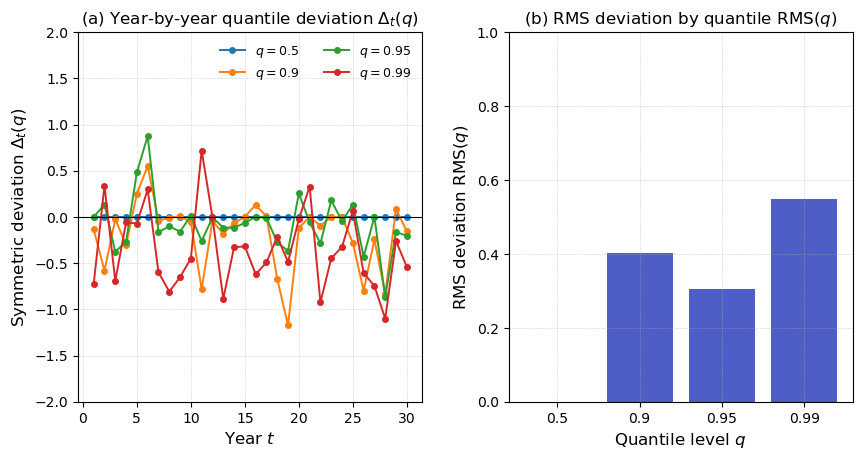

✅ Saved -> sr_runs/fig2_temporal_validation_baseline.png


In [27]:
# =====================================================
# Figure 2: Temporal validation of annual loss distributions
# =====================================================
import numpy as np
import matplotlib.pyplot as plt

# ---------- Build full annual loss matrix ----------
T = len(candidates_new[0].annual_losses)
Nj = len(candidates_new)
loss_full = np.vstack([sc.annual_losses for sc in candidates_new])  # (Nj, T)
p_full = np.ones(Nj) / Nj
years = np.arange(1, T + 1)

# ---------- Load reduced ensemble ----------
BASE_N = 100
BASE_MODE = "free"
BASE_NEST = "non_nested"
run_id = f"N{BASE_N}_{BASE_MODE}_baseline"
art = np.load(f"sr_runs/sr_run_{run_id}.npz", allow_pickle=True)

sel = np.asarray(art["selected_idx"], dtype=int)
P = np.asarray(art["selected_probs"], dtype=float)
P = P / max(P.sum(), 1e-12)
loss_red = loss_full[sel, :]
p_red = P

# ---------- Quantile comparison ----------
qs = [0.5, 0.9, 0.95, 0.99]

def weighted_quantile(values, quantiles, sample_weight=None):
    values = np.asarray(values, float)
    quantiles = np.asarray(quantiles, float)
    if sample_weight is None:
        sample_weight = np.ones(len(values))
    sorter = np.argsort(values)
    values, weights = values[sorter], sample_weight[sorter]
    cdf = np.cumsum(weights) / np.sum(weights)
    return np.interp(quantiles, cdf, values)

Q_full = np.zeros((T, len(qs)))
Q_red  = np.zeros((T, len(qs)))
for t in range(T):
    Q_full[t, :] = weighted_quantile(loss_full[:, t], qs, sample_weight=p_full)
    Q_red[t, :]  = weighted_quantile(loss_red[:, t],  qs, sample_weight=p_red)

# ---------- Compute symmetric percent deviations Δ_t(q) ----------
eps = 1e-9
diffs_spd = 2.0 * (Q_red - Q_full) / (Q_red + Q_full + eps)

# Root-mean-square deviations RMS(q)
rms_spd_by_q = np.sqrt(np.mean(diffs_spd**2, axis=0))
rms_total_spd = np.sqrt(np.mean(diffs_spd**2))

print(f"Overall RMS = {rms_total_spd:.3e}")
for q, s in zip(qs, rms_spd_by_q):
    print(f"  q={q:.2f}: RMS(q)={s:.3e}")

# ---------- Figure builder ----------
def make_fig2_temporal(diffs_spd, rms_spd_by_q, qs, years,
                       out="sr_runs/fig2_temporal_validation_baseline.png",
                       title_suffix=f"(Baseline: free weights, N={BASE_N})"):

    col_main = "#3b4cc0"

    fig = plt.figure(figsize=(10, 4.8))
    gs = fig.add_gridspec(1, 2, wspace=0.25)

    # ---------- (a) Δ_t(q) over time ----------
    ax_a = fig.add_subplot(gs[0, 0])
    for i, q in enumerate(qs):
        ax_a.plot(years, diffs_spd[:, i], "o-", label=rf"$q={q}$", lw=1.4, markersize=4)
    ax_a.axhline(0, color="k", lw=0.8)
    ax_a.set_ylim(-2, 2)
    ax_a.set_xlabel(r"Year $t$", fontsize=12)
    ax_a.set_ylabel(r"Symmetric deviation $\Delta_t(q)$", fontsize=12)
    ax_a.set_title(r"(a) Year-by-year quantile deviation $\Delta_t(q)$", fontsize=12)
    ax_a.grid(ls="--", lw=0.4, alpha=0.6)
    ax_a.legend(fontsize=9, frameon=False, ncol=2)

    # ---------- (b) RMS(q) by quantile ----------
    ax_b = fig.add_subplot(gs[0, 1])
    ax_b.bar([f"{q:g}" for q in qs], rms_spd_by_q, color=col_main, alpha=0.9)
    ax_b.set_ylim(0, 1)
    ax_b.set_xlabel(r"Quantile level $q$", fontsize=12)
    ax_b.set_ylabel(r"RMS deviation $\mathrm{RMS}(q)$", fontsize=12)
    ax_b.set_title(r"(b) RMS deviation by quantile $\mathrm{RMS}(q)$", fontsize=12)
    ax_b.grid(ls="--", lw=0.4, alpha=0.6)

    plt.tight_layout()
    plt.savefig(out, dpi=300, bbox_inches="tight")
    plt.show()
    print(f"✅ Saved -> {out}")

# ---------- Call ----------
make_fig2_temporal(diffs_spd, rms_spd_by_q, qs, years)


In [32]:
# =====================================================
# Fig. 1: Objective vs N_A + HHI  (Size-Sweep, Nested)
# =====================================================
import matplotlib.pyplot as plt
import pandas as pd

def make_fig1(df, out="sr_runs/fig1_objective_hhi_sweep_nested.png"):
    """
    Plot objective vs N_A and HHI for size-sweep runs (nested only),
    comparing equal vs free weights.
    """

    # --- Colors ---
    color_equal = "#3b4cc0"   # blue
    color_free  = "#e66101"   # orange-red
    ms = 6

    plt.figure(figsize=(7.2, 4.4))
    ax = plt.gca()

    # ---------- Primary axis: Objective ----------
    for mode, color, label in [
        ("equal", color_equal, "Equal weights"),
        ("free",  color_free,  "Free weights")
    ]:
        sub = df[(df["mode"] == mode) & (df["nesting"] == "nested")].sort_values("N_A")
        if len(sub) == 0:
            continue
        ax.plot(sub["N_A"], sub["objective"], "-o", ms=ms, color=color, label=label)

    ax.set_xlabel("Number of selected scenarios", fontsize=14)
    ax.set_ylabel("Fit objective (lower is better)", fontsize=14)
    ax.tick_params(axis="both", labelsize=12)
    ax.grid(True, linestyle="--", linewidth=0.4, alpha=0.6)

    # ---------- Secondary axis: HHI ----------
    ax2 = ax.twinx()
    for mode, color in [("equal", color_equal), ("free", color_free)]:
        sub = df[(df["mode"] == mode) & (df["nesting"] == "nested")].sort_values("N_A")
        if len(sub) == 0:
            continue
        ax2.plot(sub["N_A"], sub["hhi"], ":", marker="s", ms=ms-1,
                 color=color, label=f"HHI ({mode})")

    ax2.set_ylabel("Herfindahl–Hirschman Index (HHI)", fontsize=14)
    ax2.tick_params(axis="y", labelsize=12)

    # ---------- Combined legend ----------
    lines1, labels1 = ax.get_legend_handles_labels()
    lines2, labels2 = ax2.get_legend_handles_labels()
    ax.legend(lines1 + lines2, labels1 + labels2,
              loc="best", fontsize=11, frameon=False)

    # ---------- Title and layout ----------
    #plt.title("Scenario Reduction Performance vs Ensemble Size\n(Nested, pₘᵢₙ = 0)", fontsize=15)
    plt.tight_layout()
    plt.savefig(out, dpi=300)
    plt.show()
    print(f"✅ Saved -> {out}")


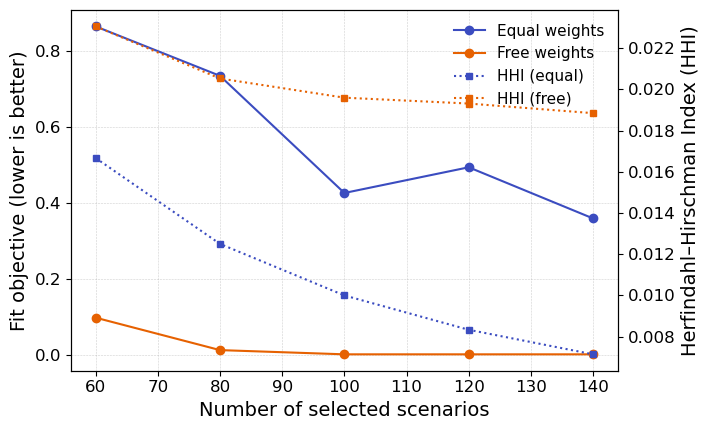

✅ Saved -> sr_runs/fig1_objective_hhi_sweep_nested.png


In [33]:
df = pd.read_csv("sr_runs/fig_hhi_runs_all.csv")
make_fig1(df)
